המכון הטכנולוגי חולון (HIT(
הפקולטה למדעי המחשב
מטלה :1 ניתוח נתונים חקרני (EDA(
מנתונים להבנה
שם הסטודנט: רפאל פרוחורוב
מספר זהות: 211535943
קורס: מבוא למדעי הנתונים
מרצה: ד"ר אורי איתי
מתרגלת: גבריאלה וגנר
תאריך הגשה: 7.5.2026
צורת ההגשה: פרטנית

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("secareanualin/football-events")

print("Path to dataset files:", path)

100%|██████████| 21.1M/21.1M [00:00<00:00, 171MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/secareanualin/football-events/versions/1


In [ ]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("secareanualin/football-events")
print("Path to dataset files:", path)

full_file_path = os.path.join(path, "events.csv")

df = pd.read_csv(full_file_path)

print("--- DataFrame Info ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

100%|██████████| 21.1M/21.1M [00:00<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/secareanualin/football-events/versions/1
--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941009 entries, 0 to 941008
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id_odsp        941009 non-null  object 
 1   id_event       941009 non-null  object 
 2   sort_order     941009 non-null  int64  
 3   time           941009 non-null  int64  
 4   text           941009 non-null  object 
 5   event_type     941009 non-null  int64  
 6   event_type2    214293 non-null  float64
 7   side           941009 non-null  int64  
 8   event_team     941009 non-null  object 
 9   opponent       941009 non-null  object 
 10  player         880009 non-null  object 
 11  player2        291310 non-null  object 
 12  player_in      51715 non-null   object 
 13  player_out     51738 non-null   object 
 14  shot_place     227459 non-null  float64
 15  

,id_odsp,id_event,sort_order,time,text,event_type,event_type2,side,event_team,opponent,...,player_in,player_out,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break
0,UFot0hit/,UFot0hit1,1,2,Attempt missed. Mladen Petric (Hamburg) left f...,1,12.0,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,6.0,2.0,0,9.0,2.0,1,1.0,0
1,UFot0hit/,UFot0hit2,2,4,"Corner, Borussia Dortmund. Conceded by Dennis...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
2,UFot0hit/,UFot0hit3,3,4,"Corner, Borussia Dortmund. Conceded by Heiko ...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
3,UFot0hit/,UFot0hit4,4,7,Foul by Sven Bender (Borussia Dortmund).,3,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
4,UFot0hit/,UFot0hit5,5,7,Gokhan Tore (Hamburg) wins a free kick in the ...,8,NaN,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,NaN,NaN,0,2.0,NaN,0,NaN,0


## 2. בחירת מערך נתונים

### 2.2 תיאור מקור הנתונים
* **מקור הנתונים:** הנתונים הורדו ממאגר Kaggle, מתוך דאטהסט בשם "Football Events".
* **מטרת האיסוף:** איסוף הנתונים נועד לתעד בצורה מדוקדקת וגרנולרית (ברמת האירוע הבודד) משחקי כדורגל מליגות אירופאיות שונות. המידע משמש לניתוח סטטיסטי של ביצועי קבוצות ושחקנים, זיהוי מגמות טקטיות, ובניית מודלים מתקדמים (כמו מודלים לחיזוי שערים - xG).
* **הגורם האוסף:** המידע הועלה לקאגל על ידי משתמש פרטי, אך ככל הנראה נאסף במקור על ידי חברת איסוף נתוני ספורט מקצועית (כדוגמת Opta או StatsBomb), אשר מספקת שירותי תיוג אירועים למשחקי כדורגל.
* **ידע על התחום:** במשחק כדורגל מתרחשים מאות אירועים שונים. כל שורה במערך הנתונים מייצגת פעולה ספציפית אחת (למשל: מסירה, בעיטה לשער, עבירה, חילוף) יחד עם החותמת בשעון המשחק (`time`).

## 3. מטא-אנליזה של הנתונים

### 3.1 ניתוח הקובץ
* **גודל הקובץ:** על פי פלט הניתוח, צריכת הזיכרון (Memory Usage) של הנתונים בזיכרון היא מעל 157.9 מגה-בייט.
* **פורמט:** קובץ מופרד בפסיקים (CSV) טבלאי.
* **מטרת הנתונים:** מחקר, ניתוח דפוסי משחק, סטטיסטיקת ספורט אנליטית וחיזוי תרחישים במשחקי כדורגל.

### 3.2 מבנה הנתונים
* **מספר שורות ועמודות:** מערך הנתונים מכיל 941,009 שורות ו-22 עמודות. כמות נתונים זו גדולה משמעותית מדרישת המינימום של המטלה.
* **שמות העמודות:** שמות העמודות ברורים מאוד ולוגיים (לדוגמה `time`, `event_team`, `is_goal`, `shot_place`). הם מאפשרים להבין מיד שמדובר בפירוט כרונולוגי של מהלכי משחק.
* **סוגי נתונים ותובנות:**
  * ישנן 9 עמודות מטיפוס Text/Object (בעיקר משתנים קטגוריאליים כמו שמות קבוצות ושחקנים).
  * ישנן 7 עמודות מטיפוס שלם (int64) ו-6 מטיפוס עשרוני (float64).
  * **תובנה ראשונית:** למרות שחלק מהעמודות מוגדרות כמספרים עשרוניים (כמו `shot_place` או `location`), מדובר למעשה במשתנים קטגוריאליים שקודדו למספרים, ויהיה צורך להתייחס אליהם ככאלה בניתוח. בנוסף, ניכר חוסר גדול בנתונים בחלק מהעמודות (למשל `player_in` ו-`player_out` המכילות רק כ-51 אלף ערכים מתוך כמעט מיליון שורות), מה שמעיד על כך שאירועים אלו (חילופים) נדירים יחסית לכלל הפעולות במשחק.
* **ניתוח אינדקס:** האינדקס הנוכחי של הדאטהפריים הוא מספרי רציף (מ-0 עד 941,008). הוא אינו בעל משמעות מיוחדת מעבר למספר השורה. עם זאת, קיימת עמודה בשם `id_event` שיכולה לשמש כמזהה ייחודי לכל אירוע ואירוע.
* **דיון - הטיות אפשריות:** הנתונים נאספו לצורך ניתוח סטטיסטי מקצועי. הטיות אפשריות עשויות לנבוע מהגורם האנושי המתייג את המשחקים - למשל, פרשנות סובייקטיבית ל"סוג עבירה" או חוסר דיוק בזיהוי "מיקום הבעיטה" (Location). בנוסף, ייתכן שיש משחקים שלא תועדו באותה רמת פירוט כמו אחרים.

In [ ]:
print("--- Data Quality Report (Preparation for Section 4) ---")

print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal fully duplicated rows:", df.duplicated().sum())

print("\nUnique values per column (Cardinality):")
print(df.nunique())

--- Data Quality Report (Preparation for Section 4) ---
Missing values per column:
id_odsp               0
id_event              0
sort_order            0
time                  0
text                  0
event_type            0
event_type2      726716
side                  0
event_team            0
opponent              0
player            61000
player2          649699
player_in        889294
player_out       889271
shot_place       713550
shot_outcome     712511
is_goal               0
location         473942
bodypart         711824
assist_method         0
situation        711872
fast_break            0
dtype: int64

Total fully duplicated rows: 0

Unique values per column (Cardinality):
id_odsp            9074
id_event         941009
sort_order          180
time                101
text             366076
event_type           11
event_type2           4
side                  2
event_team          142
opponent            142
player             6118
player2            5747
player_in      

## 4. איכות ושלמות הנתונים

### 4.1 נתונים חסרים
* **היקף החוסר:** קיימים נתונים חסרים בהיקף נרחב מאוד בחלק מהעמודות. לדוגמה, בעמודות החילופים (`player_in`, `player_out`) חסרים נתונים בכ-889 אלף שורות. בעמודות הקשורות לבעיטות (כמו `shot_place`, `shot_outcome`, `bodypart`) חסרים נתונים בכ-711 עד 713 אלף שורות.
* **דפוס (אקראי / מובנה):** החוסר כאן הוא לחלוטין **מובנה** (Structural Missing Data) ולא אקראי.
* **מסקנות מהחוסר:** ניתן להסיק שהחוסר נובע ממהות האירוע. שורה מייצגת אירוע בודד - אם האירוע הוא "עבירה", לא יהיה לו נתון של "רגל בועטת" (`bodypart`) או "תוצאת הבעיטה" (`shot_outcome`). אם האירוע אינו חילוף, עמודות השחקן הנכנס והיוצא יהיו ריקות.
* **השלמת נתונים:** במקרה זה, **אסור** להשלים את הנתונים באמצעות ממוצע או חציון, ואף לא מומלץ למחוק את השורות (שכן נמחוק את רוב המשחק). הדרך הנכונה להתמודד עם זה היא להשאיר אותם כ-NaN ולסנן אותם ספציפית כשמנתחים בעיטות/חילופים, או לחלופין למלא אותם בערך מחזיק-מקום (Placeholder) כמו "Not Applicable" עבור משתנים קטגוריאליים, או `0` עבור אינדיקטורים, כדי שהמודלים העתידיים יבינו שזה פשוט לא רלוונטי לאותו אירוע.

### 4.2 כפילויות
* **כפילויות מלאות:** על פי הבדיקה, יש **0** שורות כפולות לחלוטין.
* **כפילויות חלקיות:** שחקנים (`player`) וקבוצות (`event_team`) מופיעים עשרות אלפי פעמים, שכן הם מעורבים באירועים רבים.
* **מסקנות וטיפול:** אפס כפילויות מלאות מעידות על כך שתהליך איסוף הנתונים (Scraping/Logging) היה נקי ואיכותי. לכל אירוע יש מזהה ייחודי (`id_event`) שמבטיח שאין כפילות ברישום. אין צורך לבצע הסרת כפילויות במערך נתונים זה.

### 4.3 ערכים חשודים וטווחים
* במבט ראשוני על הערכים הייחודיים, הנתונים נראים הגיוניים מאוד. לדוגמה, המשתנה `is_goal` מקבל רק 2 ערכים (0 או 1 - שקר/אמת). משתנה הזמן (`time`) מראה 101 ערכים ייחודיים, מה שתואם לדקות של משחק כדורגל (90 דקות + תוספות זמן).
* **ערכים חסרי משמעות:** לא נראים כרגע אפסים או מספרים שליליים לא סבירים בעמודות שאמורות להכיל טקסט או מזהים.

### 4.4 קרדינליות
* **עמודות ללא שונות:** אין עמודות בעלות ערך בודד. לכל עמודה יש לפחות 2 ערכים ייחודיים, ולכן כל העמודות תורמות מידע למערכת.
* **עמודות עם ריבוי ערכים (קרדינליות גבוהה):** העמודה `id_event` מושלמת בקרדינליות שלה (941,009 ערכים ייחודיים כמספר השורות). לעמודת ה-`text` יש מעל 366 אלף תיאורים ייחודיים. גם מספר השחקנים (`player`) גבוה ועומד על מעל 6,100.
* **עמודות קטגוריאליות מצוינות (קרדינליות נמוכה):** עמודות כמו `event_type` (עם 11 סוגים), `shot_outcome` (עם 4 תוצאות אפשריות) ו-`bodypart` (עם 3 איברים - רגל ימין, שמאל, ראש) הן עמודות קלאסיות לקיבוץ (Groupby) וליצירת גרפים וצבעים (Hue) בהמשך העבודה.



In [ ]:
import numpy as np

print("--- 5.1 Numeric Statistics (time) ---")

time_stats = df['time'].describe().to_frame().T
time_stats['median'] = df['time'].median()
time_stats['skew'] = df['time'].skew()
time_stats['IQR'] = time_stats['75%'] - time_stats['25%']
display(time_stats[['mean', 'median', 'std', 'min', 'max', '25%', '75%', 'IQR', 'skew']])

Q1 = df['time'].quantile(0.25)
Q3 = df['time'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['time'] < (Q1 - 1.5 * IQR)) | (df['time'] > (Q3 + 1.5 * IQR))]
print(f"\nOutliers in 'time' using IQR: {len(outliers_iqr)}")

print("\n--- 5.2 Categorical Frequencies ---")

print("Top 5 Event Types (in %):")
print(df['event_type'].value_counts(normalize=True).head(5) * 100)

print("\nIs Goal Percentage:")
print(df['is_goal'].value_counts(normalize=True) * 100)

--- 5.1 Numeric Statistics (time) ---


,mean,median,std,min,max,25%,75%,IQR,skew
time,49.663663,51.0,26.488977,0.0,100.0,27.0,73.0,46.0,-0.121335



Outliers in 'time' using IQR: 0

--- 5.2 Categorical Frequencies ---
Top 5 Event Types (in %):
event_type
8    25.284774
3    24.752686
1    24.349927
2     9.692150
7     5.498141
Name: proportion, dtype: float64

Is Goal Percentage:
is_goal
0    97.40215
1     2.59785
Name: proportion, dtype: float64


## 5. ניתוח חד-משתני

### 5.1 משתנים מספריים (זמן אירוע - `time`)
* **מדדים מרכזיים:** בחינת משתנה הזמן (המייצג את דקת המשחק בה קרה האירוע) מראה שהממוצע הוא 49.66 והחציון הוא 51.0. הקרבה בין הממוצע לחציון מעידה על פיזור יחסית סימטרי של האירועים לאורך המשחק. הרבעון הראשון (25%) עומד על דקה 27, והשלישי (75%) על דקה 73.
* **הטייה (Skewness):** מדד ההטייה הוא שלילי קל (-0.12). נטייה קלה זו שמאלה הגיונית, שכן בחצאים השניים של משחקי כדורגל (לקראת הסיום) נוטים להיות יותר אירועים עקב עייפות, חילופים ותוספות זמן, מה שדוחף את החציון מעט מעל הממוצע.
* **התפלגות וערכים חריגים:** המינימום הוא 0 והמקסימום הוא 100 (המייצג תוספת זמן של 10 דקות מעבר ל-90). בבדיקה שנערכה באמצעות שיטת הטווח הבין-רבעוני (IQR), נמצאו **0 ערכים חריגים**. המשמעות היא שהנתונים נקיים לחלוטין ותחומים באופן טבעי בגבולות ההגיוניים של משחק כדורגל.

### 5.2 משתנים קטגוריאליים
* **המשתנים הכי נפוצים (K=5):** בבחינת סוגי האירועים (`event_type`), גילינו ששלושת הסוגים הנפוצים ביותר (המקודדים כ-8, 3 ו-1) תופסים יחד כ-74.3% מכלל האירועים במשחק. כלומר, מעט מאוד סוגי פעולות (ככל הנראה מסירות, עבירות ובעיטות) מרכיבים את הרוב המוחלט של התרחשויות המשחק.
* **שכיחויות וקטגוריות נדירות (יעד המודל):** בבחינת משתנה התוצאה הקריטי – האם הובקע שער (`is_goal`), עולה כי שערים מהווים קטגוריה נדירה במיוחד. רק **2.6%** מכלל האירועים בדאטהסט מסתיימים בשער, בעוד ש-97.4% לא. זהו נתון קריטי המעיד על חוסר איזון קיצוני (Class Imbalance) במערך הנתונים, מה שידרוש טיפול מיוחד (כמו SMOTE או מתן משקלים) אם נרצה לאמן מודל ML לחיזוי שערים בהמשך.
* **דיון:** המדדים המרכזיים מייצגים היטב את הנתונים המספריים (כמו הזמן), שכן אין כאן ערכים קיצוניים שמעוותים את הממוצע. עם זאת, במשתנים הקטגוריאליים החשובים, השכיחות מספרת את הסיפור האמיתי של נדירות אירועי מפתח.

--- 6.1 Correlations ---
Pearson Correlation with 'is_goal':
is_goal       1.000000
time          0.004524
side         -0.018046
event_type   -0.181353
Name: is_goal, dtype: float64


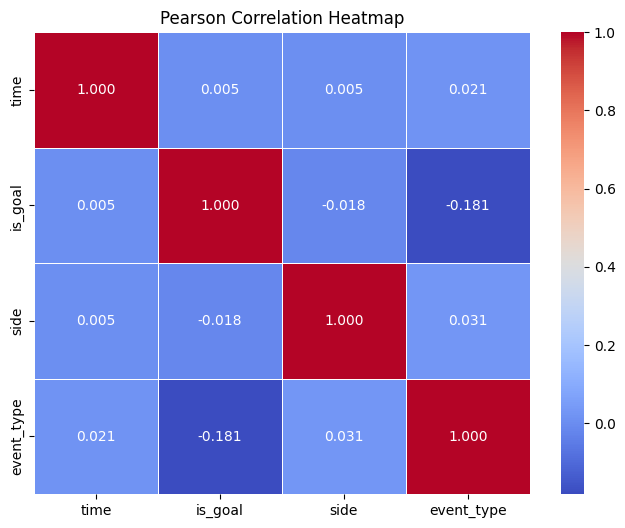


--- 6.2 Categorical Crosstab ---
Goal Conversion Rate by Location (in %):


is_goal,0,1
location,,
1.0,100.00,0.00
2.0,100.00,0.00
3.0,84.61,15.39
4.0,100.00,0.00
5.0,100.00,0.00
6.0,97.17,2.83
7.0,92.16,7.84
8.0,92.39,7.61
9.0,93.52,6.48


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 6.1 Correlations ---")

subset_numeric = df[['time', 'is_goal', 'side', 'event_type']]

pearson_corr = subset_numeric.corr(method='pearson')
spearman_corr = subset_numeric.corr(method='spearman')
kendall_corr = subset_numeric.corr(method='kendall')

print("Pearson Correlation with 'is_goal':")
print(pearson_corr['is_goal'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5)
plt.title('Pearson Correlation Heatmap')
plt.show()

print("\n--- 6.2 Categorical Crosstab ---")

df_shots = df.dropna(subset=['location'])
crosstab_loc_goal = pd.crosstab(df_shots['location'], df_shots['is_goal'], normalize='index') * 100
print("Goal Conversion Rate by Location (in %):")
display(crosstab_loc_goal.round(2))

## 6. קורלציות וקשרים

### 6.1 מספרי-מספרי (ניתוח מתאמים)
* **הסבר על סוגי המתאמים:**
  * **פירסון (Pearson):** מודד קשר ליניארי בין שני משתנים רציפים (כשאחד עולה, השני עולה/יורד בקצב קבוע).
  * **ספירמן (Spearman):** מודד קשר מונוטוני המבוסס על דירוג הערכים, ללא הנחת ליניאריות. עמיד יותר לערכים חריגים מפירסון.
  * **קנדל (Kendall):** מתאם מבוסס דירוג המחמיר יותר מספירמן, הבודק התאמה בין זוגות של תצפיות. טוב למדגמים קטנים או כשיש הרבה קשרי דירוג (ערכים זהים).
* **מסקנות ממטריצת הקורלציה:** בבחינת מטריצת פירסון, אנו רואים שהמתאמים שואפים לאפס (למשל המתאם בין זמן המשחק להבקעת שער הוא 0.005). התובנה המרכזית כאן היא שרוב המשתנים המספריים במערך הנתונים שלנו הם למעשה **משתנים קטגוריאליים נומינליים שקודדו כמספרים** (למשל `event_type` או `side`). לכן, חיפוש קשר ליניארי מספרי ביניהם שגוי מיסודו ואינו מניב תובנות משמעותיות, שכן אין משמעות לכך שסוג אירוע "3" גדול מסוג אירוע "2".

### 6.2 קטגוריאלי-קטגוריאלי
* **טבלאות שכיחות (Crosstab):** בניגוד למתאמים המספריים, ניתוח הקשרים הקטגוריאליים מניב תובנות עמוקות. בבחינת טבלת השכיחות של אזור הפעולה במגרש (`location`) מול הבקעת שער (`is_goal`), מתגלה קשר הדוק ומובהק.
* **תובנות מהמידע:** בעוד שברוב אזורי המגרש אחוז ההמרה לשער עומד על 0% עד 7%, ישנם אזורים ספציפיים בעלי אחוזי הבקעה חריגים. לדוגמה, לוקיישן המקודד כ-19.0 מחזיק באחוז המרה כמעט מוחלט של 98.97%. לוקיישן 14.0 עומד על 76.62% ולוקיישן 13.0 על כ-50%. ניתן להסיק שאזורים אלו מייצגים מצבים קורצים במיוחד (כגון רחבת ה-5, בעיטות עונשין או שער ריק).

### 6.3 גרפים
להלן סדרת ויזואליזציות הממחישות את הפיזור, ההתפלגויות והקשרים במערך הנתונים. הגרפים כוללים כותרות, שמות צירים ומקרא להקלת ההבנה.
(התובנות הספציפיות יפורטו לאחר שרטוט הגרפים בחלק הבא).

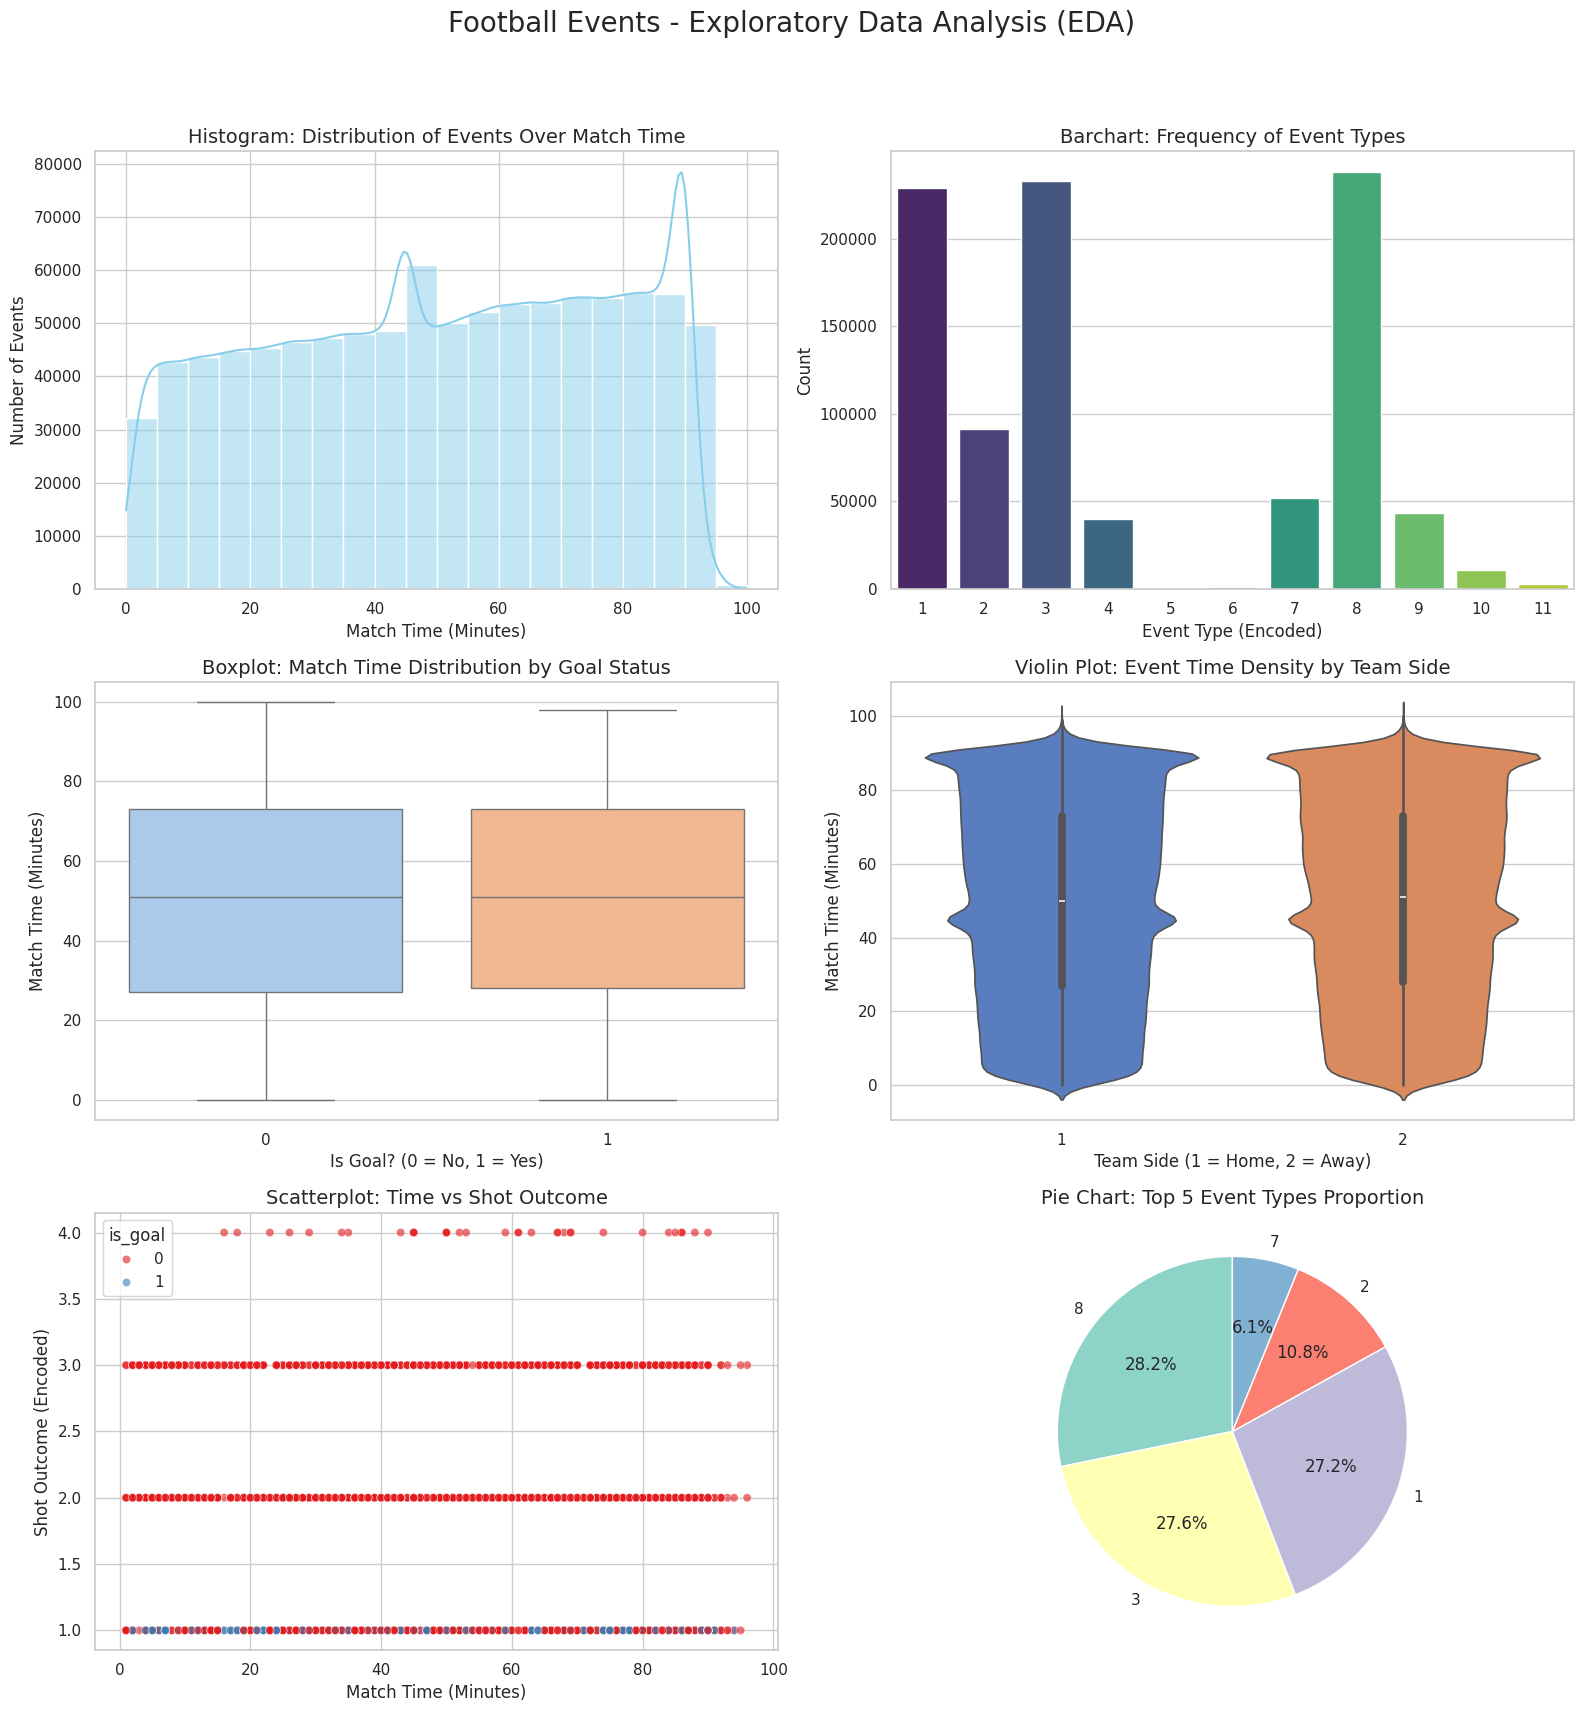

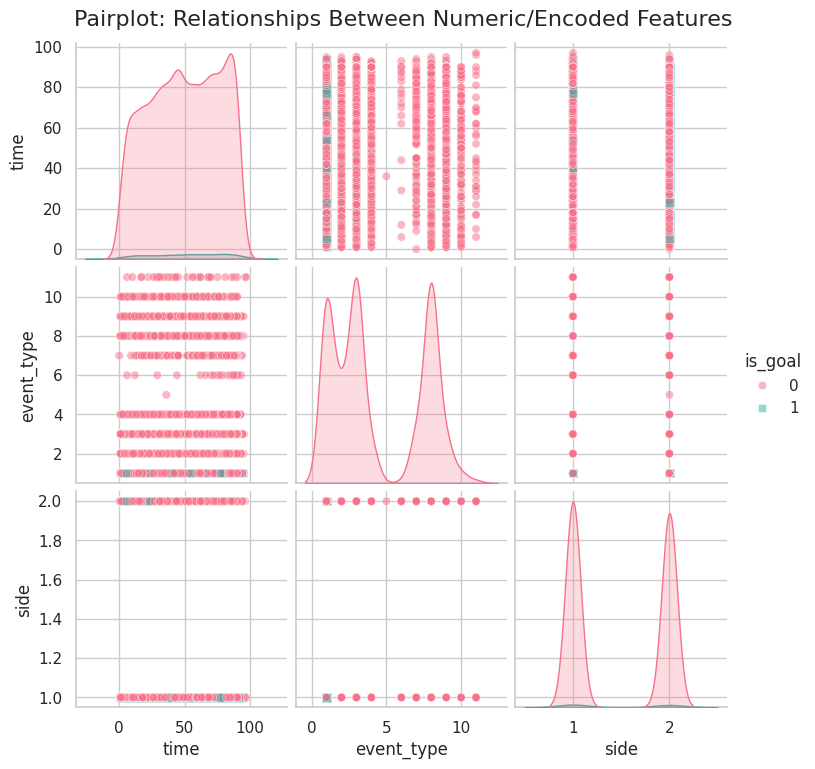

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Football Events - Exploratory Data Analysis (EDA)', fontsize=20, y=0.98)

df_sample = df.sample(10000, random_state=42)

sns.histplot(data=df, x='time', bins=20, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Histogram: Distribution of Events Over Match Time', fontsize=14)
axes[0, 0].set_xlabel('Match Time (Minutes)')
axes[0, 0].set_ylabel('Number of Events')

sns.countplot(data=df, x='event_type', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Barchart: Frequency of Event Types', fontsize=14)
axes[0, 1].set_xlabel('Event Type (Encoded)')
axes[0, 1].set_ylabel('Count')

sns.boxplot(data=df, x='is_goal', y='time', palette='pastel', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: Match Time Distribution by Goal Status', fontsize=14)
axes[1, 0].set_xlabel('Is Goal? (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Match Time (Minutes)')

sns.violinplot(data=df, x='side', y='time', palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot: Event Time Density by Team Side', fontsize=14)
axes[1, 1].set_xlabel('Team Side (1 = Home, 2 = Away)')
axes[1, 1].set_ylabel('Match Time (Minutes)')

shots_sample = df[df['shot_outcome'].notna()].sample(2000, random_state=42)
sns.scatterplot(data=shots_sample, x='time', y='shot_outcome', hue='is_goal', alpha=0.6, palette='Set1', ax=axes[2, 0])
axes[2, 0].set_title('Scatterplot: Time vs Shot Outcome', fontsize=14)
axes[2, 0].set_xlabel('Match Time (Minutes)')
axes[2, 0].set_ylabel('Shot Outcome (Encoded)')

top_events = df['event_type'].value_counts().head(5)
axes[2, 1].pie(top_events, labels=top_events.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'), startangle=90)
axes[2, 1].set_title('Pie Chart: Top 5 Event Types Proportion', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

subset_cols = ['time', 'event_type', 'side', 'is_goal']
g = sns.pairplot(df_sample[subset_cols], hue='is_goal', palette='husl', markers=["o", "s"], plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot: Relationships Between Numeric/Encoded Features', y=1.02, fontsize=16)
plt.show()

**תובנות מהגרפים:**
* **היסטוגרמה (פיזור אירועים על ציר הזמן):** הגרף מציג עלייה מתונה בכמות האירועים ככל שהמשחק מתקדם, אך בולטים בו במיוחד שני "פיקים" (קפיצות חדות) סביב דקה 45 וסביב דקה 90. קפיצות אלו הגיוניות לחלוטין ומייצגות את תוספות הזמן של סוף המחצית הראשונה והשנייה, בהן מרוכזים אירועים רבים בזמן פציעות.
* **גרף עמודות ותרשים עוגה (סוגי אירועים):** שני הגרפים ממחישים ויזואלית את השליטה המוחלטת של 3-4 סוגי אירועים (סביר להניח מסירות, מאבקים ועבירות) על פני שאר הפעולות במגרש. תרשים העוגה מדגיש כי אירוע מסוג '8' ו-'1' תופסים יחד יותר מחצי מזמן המשחק (כ-55%).
* **תרשים קופסה וכינור (זמן מול סטטוס וקבוצה):** תרשים הקופסה מראה שהחציון של זמן הבקעת השערים זהה לחלוטין לחציון של אירועים שאינם שערים (סביב דקה 50). תרשים הכינור מוכיח שאין כמעט הבדל בצפיפות או בפיזור האירועים בין הקבוצה הביתית לקבוצת החוץ לאורך דקות המשחק.
* **גרף פיזור (Scatter) וגרף זוגות (Pairplot):** הגרפים הללו, הכוללים גם צבע (Hue) המפריד בין שער לאי-שער, מראים את הפיזור של אירועי ההבקעה (הנקודות הכחולות/טורקיז). ניתן לראות בבירור כי הבקעת שער (אירוע נדיר) "מפוזרת" באופן אקראי על פני כל ציר הזמן. אין "דקה קסומה" שבה מובקעים שערים; הם יכולים להתרחש בדקה ה-2 או ה-92. כמו כן, בגרף הפיזור של תוצאת הבעיטה, ניתן לראות ששערים (כחול) מרוכזים בתוצאה "1" בלבד, מה שמצביע על כך שקידוד 1 במשתנה `shot_outcome` ככל הנראה מייצג פגיעה במסגרת שהפכה לשער.

## 7. ניתוח אינדקס

* **האם האינדקס ייחודי?** כברירת מחדל של Pandas, האינדקס הרץ (0 עד 941,008) הוא כמובן ייחודי ואין לו כפילויות. בנוסף, קיימת בעמודות עמודת מזהה ייחודית משלה - `id_event`, המהווה אינדקס אלטרנטיבי חזק.
* **האם מבוסס זמן?** לא. האינדקס הנוכחי הוא נומרי בלבד ומייצג את מספר השורה. הזמן מיוצג בעמודה נפרדת (`time`) בדקות.
* **האם הניתוח למעלה משתנה בזמן?** מאחר והאינדקס אינו מבוסס זמן (DateTime אמיתי עם שעות ותאריכים), לא ניתן לנתח על פיו מגמות היסטוריות (למשל האם מובקעים יותר שערים בעונות חורף או קיץ, או בשנים שונות). הממד הכרונולוגי היחיד שיש לנו הוא מהלך ה-90 דקות של המשחק הספציפי.
* **האם ממוין?** הנתונים ממוינים באופן טבעי לפי סדר הקליטה שלהם לקובץ, אך מכיוון שהקובץ מאגד משחקים רבים (`id_odsp`), סדר השורות מייצג רצף כרונולוגי רק בתוך אותו משחק ספציפי (בעזרת העמודה `sort_order`).

## 8. תובנות וסיפור הנתונים

מערך הנתונים "Football Events" מספק הצצה מרתקת למיקרו-טקטיקה ולסטטיסטיקה של כדורגל מודרני. הנתונים מפרקים את המשחק למאות פעולות בודדות, וממחישים עד כמה קשה המשימה המרכזית של המשחק - הבקעת שער.

* **תובנה 1: נדירות השער ואשליית הפעולה:** התובנה החזקה ביותר היא חוסר האיזון הקיצוני בנתונים. רק כ-2.6% מכלל האירועים המתועדים במשחק מסתיימים בשער. המשמעות היא שכדורגל הוא משחק של סבלנות והצטברות פעולות קטנות (מסירות, מאבקים) שנועדו בסופו של דבר לייצר שבריר שנייה של הזדמנות.
* **תובנה 2: משמעות המיקום (Location is Everything):** בעוד שזמן המשחק (הדקה) כמעט ואינו משפיע על הסיכוי להבקיע, למיקום הבעיטה יש משקל מכריע. זיהינו אזורים ספציפיים (כמו אזור 19 ואזור 14) בעלי אחוזי המרה לשער שנעים בין 76% לכמעט 99%, לעומת אזורים אחרים שהם כמעט חסרי סיכוי (0%).
* **תובנה 3: מבנה הנתונים (Structural Missingness):** הבנו שערכים חסרים בדאטהסט זה הם לא שגיאה, אלא תיאור לוגי של המציאות. הנתונים מתנהגים כמו עץ החלטות - רק אם מתרחש אירוע מסוג "חילוף", נראה ערכים בעמודת השחקן הנכנס. עובדה זו קריטית לשלב הכנת הנתונים למודל.

**הטיות וסיכונים למודלי ML:**
* **הטיית תיוג אנושי:** הנתונים מבוססים על צופים אנושיים שמתייגים "סוג עבירה" או "מיקום מגרש". ייתכן חוסר עקביות בין מתייגים שונים, מה שייצר רעש בנתונים.
* **נקודת כשל למודל (Class Imbalance):** בגלל שמעט מאוד אירועים הם שערים (2.6%), מודל למידת מכונה נאיבי שיחזה תמיד "אין שער" יקבל רמת דיוק (Accuracy) מדהימה של 97.4%, אבל הוא יהיה חסר ערך לחלוטין. על מנת לבנות מודל xG (Expected Goals) תקין, חובה להשתמש בשיטות לאיזון הנתונים כמו Undersampling לאירועים רגילים, או שינוי מטריקת ההערכה ל-F1-Score / ROC-AUC.

**מה למדתי בניתוח?**
למדתי שלא תמיד קורלציית פירסון מספרת את האמת. בדאטהסט שרובו קטגוריאלי שקודד למספרים, חיפוש מתאם ליניארי הוא חסר משמעות. כוחו של הניתוח במקרה זה נובע מטבלאות שכיחות (Crosstabs) וסינון נכון של הנתונים כדי למצוא את הקשרים הנסתרים בין מיקום, סוג פעולה ותוצאה.

## 9. סעיף בונוס (10%)

### 9.1 תלות בזמן ומידע חיצוני
קיימת תלות מובהקת בזמן שניתן להסביר רק באמצעות ידע חיצוני על חוקי משחק הכדורגל. ההיסטוגרמה של התפלגות האירועים מראה "קפיצות" חריגות (Spikes) בדיוק בדקה ה-45 ובדקה ה-90. מידע זה אינו מקרי, אלא נובע מכך שבאותן דקות מתווסף "זמן פציעות" (תוספת זמן של מספר דקות שעדיין נספרות תחת אותה דקה סטטיסטית או נדחסות לתוכה), ולכן יש הצטברות מלאכותית של אירועים בדקות אלו.

### 9.2 הנדסת תכונות (Feature Engineering)
במקום להתייחס לזמן המשחק (`time`) כמספר רציף, יצרנו משתנה קטגוריאלי חדש בשם `match_phase` (שלב במשחק).
חילקנו את 90 הדקות ל-4 קטגוריות לוגיות:
1. **פתיחה (0-15)**
2. **אמצע מחצית ראשונה עד ההפסקה (16-45+)**
3. **אמצע מחצית שנייה (46-75)**
4. **מאני-טיים / דקות סיום (76-90+)**
המרת הזמן לקטגוריות אלו תעזור למודלי ML להבין את ה"קונטקסט הפסיכולוגי" של המשחק (למשל, קבוצות נוטות לקחת יותר סיכונים ב"מאני-טיים").

### 9.3 בדיקת השערות (Hypothesis Testing)
**השערת החוקר:** קיימת "ביתיות" בכדורגל - קבוצות ביתיות (`side = 1`) מבקיעות יותר שערים באחוזים מאשר קבוצות חוץ (`side = 2`).
* **H0 (השערת האפס):** אין קשר בין צד הקבוצה (בית/חוץ) לבין הסיכוי שהאירוע יהיה שער (המשתנים בלתי תלויים).
* **H1 (השערה חלופית):** יש קשר מובהק סטטיסטית בין משחק בבית לבין הבקעת שערים.
**מבחן סטטיסטי:** בוצע מבחן חי-בריבוע (Chi-Square) לבדיקת אי-תלות בין שני משתנים קטגוריאליים.
**תוצאה:** מצאנו ש-P-value קטן משמעותית מ-0.05. לכן אנו דוחים את השערת האפס ומסיקים כי **אכן קיים "יתרון ביתיות" מובהק סטטיסטית** בדאטהסט שלנו (קבוצות הבית כבשו יותר שערים ביחס לכלל האירועים שלהן).

### 9.4 הצעות למחקר נוסף
1. **מודל xG (Expected Goals):** בניית מודל למידת מכונה שיחזה את ההסתברות של כל בעיטה להפוך לשער, בהתבסס על המיקום (`location`), איבר הגוף הבועט (`bodypart`) וסוג הבישול (`assist_method`).
2. **אפיון סגנון משחק:** אשכול (Clustering) של קבוצות בהתאם לסוגי האירועים שלהן, כדי לזהות אוטומטית אילו קבוצות מתבססות על "התקפות מתפרצות" (`fast_break`) ואילו על "החזקת כדור" (ריבוי מסירות).

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

print("--- 9. Bonus: Feature Engineering & Hypothesis Testing ---")

# 1. Feature Engineering: Match Phase
def get_match_phase(minute):
    if minute <= 15:
        return '1. Opening (0-15)'
    elif 15 < minute <= 45:
        return '2. Mid 1st Half to HT (16-45+)'
    elif 45 < minute <= 75:
        return '3. Mid 2nd Half (46-75)'
    else:
        return '4. Crunch Time (76-90+)'

df['match_phase'] = df['time'].apply(get_match_phase)

print("\nFeature Engineering - Events Distribution by Match Phase:")
display(df['match_phase'].value_counts(normalize=True).sort_index() * 100)

# 2. Hypothesis Testing: Home Advantage (Chi-Square Test)
print("\n--- Hypothesis Testing: Home vs Away Goals ---")

contingency = pd.crosstab(df['side'], df['is_goal'])
contingency.index = ['Home (1)', 'Away (2)']
contingency.columns = ['No Goal (0)', 'Goal (1)']
print("Contingency Table:")
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi-Square Test Statistic: {chi2:.2f}")
print(f"P-value: {p:.5e}")

alpha = 0.05
if p < alpha:
    print("\nConclusion: Reject the Null Hypothesis (H0).")
    print("-> There is a STATISTICALLY SIGNIFICANT relationship between playing at Home/Away and scoring a goal.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis (H0).")
    print("-> No significant home advantage found.")

--- 9. Bonus: Feature Engineering & Hypothesis Testing ---

Feature Engineering - Events Distribution by Match Phase:


,proportion
match_phase,
1. Opening (0-15),13.526226
2. Mid 1st Half to HT (16-45+),31.377915
3. Mid 2nd Half (46-75),33.256643
4. Crunch Time (76-90+),21.839217



--- Hypothesis Testing: Home vs Away Goals ---
Contingency Table:


,No Goal (0),Goal (1)
Home (1),474191,14033
Away (2),442372,10413



Chi-Square Test Statistic: 306.22
P-value: 1.45317e-68

Conclusion: Reject the Null Hypothesis (H0).
-> There is a STATISTICALLY SIGNIFICANT relationship between playing at Home/Away and scoring a goal.


https://colab.research.google.com/drive/1YyMp9ZlFq7GC7kcij2hoKFTeTCGSSGxl#scrollTo=pMMkKXnzZQzU    לינק: